In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

In [25]:
salary_df = pd.read_csv('../data/all.csv', sep='|')
print("============DATASET============:")
display(salary_df.head())

============DATASET============:


,id,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,job_benefits,company_process_time,company_size,company_industry,job_description,salary
0,1,Facility Maintenance & Smart Warehouse Manager,Bandung,IDR,Manajer/Asisten Manajer,5 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Manufaktur,Pemeliharaan",NaN,NaN,NaN,NaN,Deskripsi PekerjaanRequirements :D3/SI from re...,NaN
1,2,Procurement Department Head,Jakarta Raya,IDR,Manajer/Asisten Manajer,5 tahun,"Sarjana (S1), Diploma Pascasarjana, Gelar Prof...",Penuh Waktu,"Manufaktur,Pembelian/Manajemen Material",NaN,25 days,51 - 200 pekerja,Manajemen/Konsulting HR,Job Role: 1. Responsible for material availabi...,NaN
2,3,SALES ADMIN,Jakarta Barat,IDR,Supervisor/Koordinator,4 tahun,Sarjana (S1),Penuh Waktu,"Penjualan / Pemasaran,Penjualan Ritel","Waktu regular, Senin - Jumat;Bisnis (contoh: K...",30 days,51 - 200 pekerja,Umum & Grosir,Internal Sales & AdminJob Description :We are ...,NaN
3,4,City Operation Lead Shopee Express (Cirebon),Cirebon,IDR,Supervisor/Koordinator,5 tahun,"Sarjana (S1), Diploma Pascasarjana, Gelar Prof...",Penuh Waktu,"Pelayanan,Logistik/Rantai Pasokan","Tip;Waktu regular, Senin - Jumat;Kasual (conto...",21 days,2001 - 5000 pekerja,Retail/Merchandise,Job Description:Responsible for HSE implementa...,NaN
4,5,Japanese Interpreter,Bekasi,IDR,Pegawai (non-manajemen & non-supervisor),2 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Lainnya,Jurnalis/Editor",NaN,23 days,201 - 500 pekerja,Manajemen/Konsulting HR,Overview: Our clients is manufacture for autom...,NaN


In [26]:
print("============INFORMATION OF DATASET============:")
display(salary_df.info())

============INFORMATION OF DATASET============:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34746 entries, 0 to 34745
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34746 non-null  int64  
 1   job_title             34746 non-null  object 
 2   location              34746 non-null  object 
 3   salary_currency       34742 non-null  object 
 4   career_level          34746 non-null  object 
 5   experience_level      30205 non-null  object 
 6   education_level       34746 non-null  object 
 7   employment_type       33402 non-null  object 
 8   job_function          34746 non-null  object 
 9   job_benefits          27330 non-null  object 
 10  company_process_time  24555 non-null  object 
 11  company_size          29103 non-null  object 
 12  company_industry      33132 non-null  object 
 13  job_description       34745 non-null  object 
 14  salary                

None

In [27]:
# CHECKING DUPLICATE VALUES
print("============DUPLICATED VALUES============:") 
print(salary_df.duplicated().sum())

============DUPLICATED VALUES============:
0


In [28]:
# CHECKING MISSING VALUES
print("============MISSING VALUES (BY PERCENTAGE)============:")
missing_percent = (salary_df.isnull().sum() / len(salary_df)) * 100
print(missing_percent)

============MISSING VALUES (BY PERCENTAGE)============:
id                       0.000000
job_title                0.000000
location                 0.000000
salary_currency          0.011512
career_level             0.000000
experience_level        13.069130
education_level          0.000000
employment_type          3.868071
job_function             0.000000
job_benefits            21.343464
company_process_time    29.329995
company_size            16.240718
company_industry         4.645139
job_description          0.002878
salary                  73.084672
dtype: float64


In [29]:
# SALARY IS THE TARGET VARIABLE, SO WE DROP THE ROWS WITH MISSING SALARY
salary_df_cleaned = salary_df.dropna(subset=['salary'])
# WE CAN USE SIMPLE IMPUTER: MOST OF FREQUENT VALUE FOR CATEGORICAL FEATURES
# DEFINE CATEGORICAL FEATURES
categorical_features = ['salary_currency', 'experience_level', 'employment_type', 'job_benefits', 'company_process_time', 'company_size', 'company_industry', 'job_description']
cat_imputer = SimpleImputer(strategy='most_frequent')
salary_df_cleaned[categorical_features] = cat_imputer.fit_transform(
    salary_df_cleaned[categorical_features]
)

In [30]:
# WE CHECK AGAIN FOR MISSING VALUES
print("============MISSING VALUES AFTER IMPUTATION (BY PERCENTAGE)============:")
missing_percent_after = (salary_df_cleaned.isnull().sum() / len(salary_df_cleaned)) * 100
print(missing_percent_after)
display(salary_df_cleaned.head(15))

============MISSING VALUES AFTER IMPUTATION (BY PERCENTAGE)============:
id                      0.0
job_title               0.0
location                0.0
salary_currency         0.0
career_level            0.0
experience_level        0.0
education_level         0.0
employment_type         0.0
job_function            0.0
job_benefits            0.0
company_process_time    0.0
company_size            0.0
company_industry        0.0
job_description         0.0
salary                  0.0
dtype: float64


,id,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,job_benefits,company_process_time,company_size,company_industry,job_description,salary
5,6,KEPALA PABRIK,Balikpapan,IDR,Supervisor/Koordinator,1 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Manufaktur,Manufaktur",Asuransi kesehatan;Bisnis (contoh: Kemeja);Pro...,18 days,51 - 200 pekerja,Manufaktur/Produksi,"Tedmond Groups membuka Lowongan Kepala Pabrik,...",10500000.0
9,10,Tax Supervisor,Banten,IDR,Supervisor/Koordinator,3 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Akuntansi / Keuangan,Audit & Pajak","Tip;Asuransi kesehatan;Waktu regular, Senin - ...",22 days,51 - 200 pekerja,Konstruksi/Bangunan/Teknik,ResponsibilitiesPrepare corporate income tax (...,8000000.0
18,19,Accounting Staff,Jakarta Pusat,IDR,Pegawai (non-manajemen & non-supervisor),1 tahun,"SMA, SMU/SMK/STM, Sertifikat Professional, D3 ...",Penuh Waktu,"Akuntansi / Keuangan,Akuntansi Umum / Pembiayaan",Tip;Asuransi kesehatan;Bisnis (contoh: Kemeja)...,29 days,1- 50 pekerja,Manufaktur/Produksi,DESKRIPSI PEKERJAAN:Memeriksa dan/atau membuat...,4750000.0
22,23,Senior Staff Purchasing,Surabaya,IDR,Pegawai (non-manajemen & non-supervisor),2 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Manufaktur,Pembelian/Manajemen Material",Asuransi kesehatan;Jam Bekerja yang Panjang;Bi...,29 days,1- 50 pekerja,Elektrikal & Elektronik,Deskripsi Pekerjaan:Mampu melakukan rencana pe...,5250000.0
26,27,MARKETING COMMUNICATION & CHANNEL MANAGER,Jakarta Pusat,IDR,Manajer/Asisten Manajer,2 tahun,Tidak terspesifikasi,Penuh Waktu,"Penjualan / Pemasaran,Pemasaran/Pengembangan B...",Asuransi Gigi;Asuransi kesehatan;Parkir;Waktu ...,29 days,51 - 200 pekerja,"Konsultasi (IT, Ilmu Pengetahuan, Teknis & Tek...","SCOPE OF ROLE :To plan, develop, implement and...",15000000.0
28,29,Mechanic,Papua,IDR,Pegawai (non-manajemen & non-supervisor),1 tahun,Tidak terspesifikasi,Penuh Waktu,"Teknik,Mekanikal","Asuransi kesehatan;Waktu regular, Senin - Juma...",29 days,51 - 200 pekerja,Automobil/Mesin Tambahan Automotif/Kendaraan,Kualifikasinya :Pendidikan Minimal SMK Jurusan...,5040000.0
31,32,PPIC,Tangerang,IDR,Manajer/Asisten Manajer,5 tahun,Sarjana (S1),Penuh Waktu,"Manufaktur,Manufaktur","Asuransi kesehatan;Waktu regular, Senin - Juma...",21 days,201 - 500 pekerja,Manufaktur/Produksi,Tanggung Jawab:Membuat perencanaan produksi be...,6600000.0
34,35,C# Advanced/Senior Developer,Jakarta Timur,IDR,Supervisor/Koordinator,2 tahun,"SMA, SMU/SMK/STM, Sertifikat Professional, D3 ...",Penuh Waktu,"Komputer/Teknologi Informasi,IT-Perangkat Lunak","Tip;Asuransi kesehatan;Waktu regular, Senin - ...",5 days,1- 50 pekerja,Komputer/Teknik Informatika (Perangkat Lunak),Kualifikasi:Kandidat harus memiliki setidaknya...,9500000.0
35,36,Manager Tiktok Shop And Tiktok Live,Banten,IDR,Manajer/Asisten Manajer,1 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Penjualan / Pemasaran,E-commerce",Kasual (contoh: Kaos);Potensi Perkembangan Kar...,29 days,1- 50 pekerja,Umum & Grosir,Perusahaan yang bergerak di bidang online shop...,6500000.0
37,38,IT Software Developer Staff,Jakarta Barat,IDR,Pegawai (non-manajemen & non-supervisor),1 tahun,"Sarjana (S1), Diploma Pascasarjana, Gelar Prof...",Penuh Waktu,"Komputer/Teknologi Informasi,IT-Perangkat Lunak",Kasual (contoh: Kaos);Senin - Jum'at (HO) Seni...,21 days,501 - 1000 pekerja,Industri Berat/Mesin/Peralatan,Bachelor’s degree of Information Technology or...,6800000.0


In [31]:
def map_education_level(edu_string):
    if pd.isna(edu_string):
        return 0
    
    edu_string = str(edu_string)

    if "Doktor (S3)" in edu_string:
        return 6
    elif "Magister (S2)" in edu_string:
        return 5
    elif "Sarjana (S1)" in edu_string:
        return 4
    elif "D3 (Diploma)" in edu_string or "D4 (Diploma)" in edu_string:
        return 3
    elif "Sertifikat Professional" in edu_string:
        return 2
    elif "SMA" in edu_string:
        return 1
    else:
        return 0
salary_df_cleaned["education_level"] = salary_df_cleaned["education_level"].apply(map_education_level)

def map_benefit_level(benefit_string):
    if pd.isna(benefit_string):
        return 0
    
    benefit_string = str(benefit_string)

    score = 0

    # Benefit dasar
    if "BPJS" in benefit_string or "Asuransi kesehatan" in benefit_string:
        score = max(score, 1)

    # Bonus / Incentive
    if "Bonus" in benefit_string or "Incentive" in benefit_string or "Tip" in benefit_string:
        score = max(score, 2)

    # Benefit premium
    if "ESOP" in benefit_string or "Allowance" in benefit_string:
        score = max(score, 3)

    return score
salary_df_cleaned["benefit_level"] = salary_df_cleaned["job_benefits"].apply(map_benefit_level)

salary_df_cleaned["company_process_time"] = (
    salary_df_cleaned["company_process_time"]
    .str.replace(" days", "", regex=False)
)
salary_df_cleaned["company_process_time"] = pd.to_numeric(
    salary_df_cleaned["company_process_time"],
    errors="coerce"
)
salary_df_cleaned["career_level"] = salary_df_cleaned["career_level"].replace(
    {"Supervisor/Koordinator": 1,
     'Pegawai (non-manajemen & non-supervisor)': 2,
     'Manajer/Asisten Manajer': 3,
     'Lulusan baru/Pengalaman kerja kurang dari 1 tahun': 4,
     'CEO/GM/Direktur/Manajer Senior': 5}
)
salary_df_cleaned["experience_level"] = (
    salary_df_cleaned["experience_level"]
    .str.replace(" tahun", "", regex=False)
)
salary_df_cleaned["experience_level"] = pd.to_numeric(
    salary_df_cleaned["experience_level"],
    errors="coerce"
)
salary_df_cleaned["company_size_level"] = salary_df_cleaned["company_size"].replace(
    {"1- 50 pekerja": 0,
     '51 - 200 pekerja': 1,
     '201 - 500 pekerja': 2,
     '501 - 1000 pekerja': 3,
     '1001 - 2000 pekerja': 4,
     '2001 - 5000 pekerja': 5,
     'Lebih dari 5000 pekerja': 6,}
)
RATE_2022 = 15585
salary_df_cleaned.loc[salary_df_cleaned["salary_currency"] == "USD", "salary"] = (
    salary_df_cleaned.loc[salary_df_cleaned["salary_currency"] == "USD", "salary"] * RATE_2022
)
salary_df_cleaned.loc[salary_df_cleaned["salary_currency"] == "USD", "salary_currency"] = "IDR"
salary_df_cleaned = salary_df_cleaned.drop(columns=['job_description', 'id', "job_benefits", "company_size"])
display(salary_df_cleaned.head())

,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,company_process_time,company_industry,salary,benefit_level,company_size_level
5,KEPALA PABRIK,Balikpapan,IDR,1,1.0,4,Penuh Waktu,"Manufaktur,Manufaktur",18.0,Manufaktur/Produksi,10500000.0,2,1
9,Tax Supervisor,Banten,IDR,1,3.0,4,Penuh Waktu,"Akuntansi / Keuangan,Audit & Pajak",22.0,Konstruksi/Bangunan/Teknik,8000000.0,2,1
18,Accounting Staff,Jakarta Pusat,IDR,2,1.0,4,Penuh Waktu,"Akuntansi / Keuangan,Akuntansi Umum / Pembiayaan",29.0,Manufaktur/Produksi,4750000.0,2,0
22,Senior Staff Purchasing,Surabaya,IDR,2,2.0,4,Penuh Waktu,"Manufaktur,Pembelian/Manajemen Material",29.0,Elektrikal & Elektronik,5250000.0,1,0
26,MARKETING COMMUNICATION & CHANNEL MANAGER,Jakarta Pusat,IDR,3,2.0,0,Penuh Waktu,"Penjualan / Pemasaran,Pemasaran/Pengembangan B...",29.0,"Konsultasi (IT, Ilmu Pengetahuan, Teknis & Tek...",15000000.0,1,1


Number of outliers in salary: 764


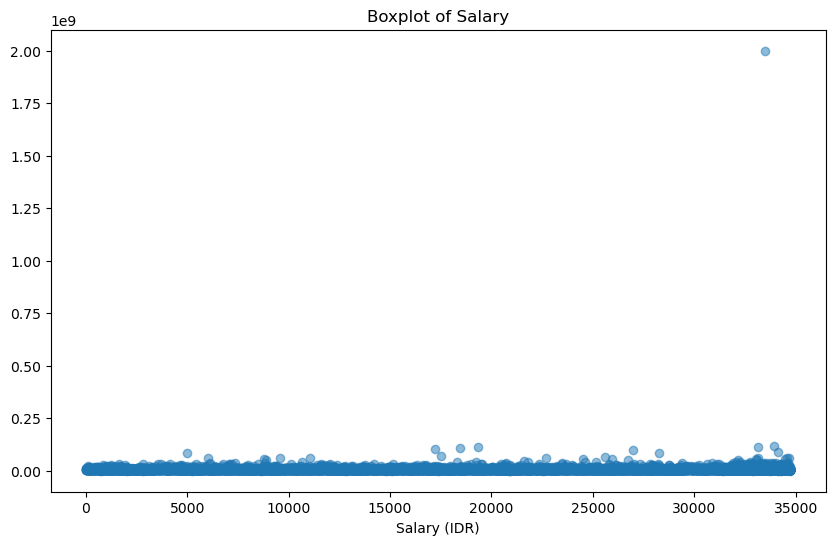

In [32]:
# CHECKING FOR OUTLIERS IN SALARY
Q1 = salary_df_cleaned['salary'].quantile(0.25)
Q3 = salary_df_cleaned['salary'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = salary_df_cleaned[(salary_df_cleaned['salary'] > upper_bound) | (salary_df_cleaned['salary'] < lower_bound)]
print(f"Number of outliers in salary: {len(outliers)}")
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(salary_df_cleaned.index, salary_df_cleaned['salary'], alpha=0.5)
plt.title('Boxplot of Salary')
plt.xlabel('Salary (IDR)')
plt.show()

Number of outliers in salary: 308


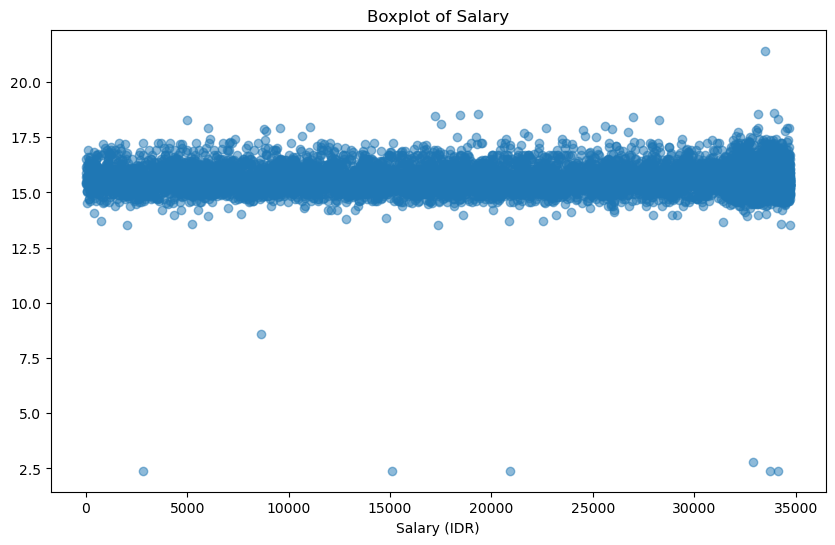

Outlier percentage: 3.29%


In [33]:
salary_df_cleaned['salary'] = np.log1p(salary_df_cleaned['salary'])
# CHECKING AGAIN FOR OUTLIERS IN SALARY
Q1 = salary_df_cleaned['salary'].quantile(0.25)
Q3 = salary_df_cleaned['salary'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = salary_df_cleaned[(salary_df_cleaned['salary'] > upper_bound) | (salary_df_cleaned['salary'] < lower_bound)]
print(f"Number of outliers in salary: {len(outliers)}")
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(salary_df_cleaned.index, salary_df_cleaned['salary'], alpha=0.5)
plt.title('Boxplot of Salary')
plt.xlabel('Salary (IDR)')
plt.show()
total_data = len(salary_df_cleaned)

outlier_percentage = (len(outliers) / total_data) * 100
print(f"Outlier percentage: {outlier_percentage:.2f}%")

In [35]:
le = LabelEncoder()
categorical_cols = ["job_title", "location", "salary_currency", "employment_type", "job_function", "company_industry"]
for col in categorical_cols:
    salary_df_cleaned[col] = le.fit_transform(salary_df_cleaned[col])
display(salary_df_cleaned.head())

,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,company_process_time,company_industry,salary,benefit_level,company_size_level
5,2654,4,0,1,1.0,4,4,21,18.0,30,16.166886,2,1
9,5564,13,0,1,3.0,4,4,1,22.0,21,15.894952,2,1
18,249,51,0,2,1.0,4,4,0,29.0,30,15.373655,2,0
22,4975,157,0,2,2.0,4,4,22,29.0,7,15.473739,1,0
26,2891,51,0,3,2.0,0,4,37,29.0,23,16.523561,1,1


In [ ]:
# salary_df_cleaned.to_csv('../data/salary_cleaned.csv', index=False)